In [ ]:
# Imports and data loading
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report
from sklearn.inspection import permutation_importance

df = pd.read_csv('../raw_data/features_enriched_data.csv')
print(f"Loaded: {df.shape}")

# Parse dates
df['last_funding_at'] = pd.to_datetime(df['last_funding_at'], errors='coerce')
df['first_funding_at'] = pd.to_datetime(df['first_funding_at'], errors='coerce')
df['founded_at'] = pd.to_datetime(df['founded_at'], errors='coerce')

# Drop unknowns
df = df[df['status_enriched'] != 'unknown'].copy()
print(f"After dropping unknown: {df.shape}")
print(f"Status distribution:\n{df['status_enriched'].value_counts()}")

Loaded: (44363, 31)
After dropping unknown: (43212, 31)
Status distribution:
status_enriched
operating    29362
closed       11031
acquired      2819
Name: count, dtype: int64


In [ ]:
# Death score function
# ============================================================

# Dataset snapshot date (latest funding date in the data)
SNAPSHOT = pd.Timestamp('2015-01-01')

# Pre-compute helper columns
df['years_since_last_funding'] = (SNAPSHOT - df['last_funding_at']).dt.days / 365.25
df['company_age_years'] = (SNAPSHOT - df['founded_at']).dt.days / 365.25


def compute_death_score(row):
    """
    Assigns a 'death score' (0-100) to operating companies.
    Higher score = more likely the company is actually dead.

    Signals (additive):
      1. Years since last funding      (max 35 pts)
      2. Never got past seed/angel     (max 25 pts)
      3. Low total funding             (max 15 pts)
      4. Single funding round          (max 10 pts)
      5. Old company still at seed     (max 10 pts)
      6. Burst then silence pattern    (max  8 pts)
      7. Missing founding date + stale (max  7 pts)
      8. Unfunded fraction of life     (max  5 pts)

    Survival signals (subtractive):
      - Reached Series B+             (-15 pts)
      - Has private equity             (-10 pts)
      - Reached Series D/E             (-10 pts)
    """
    score = 0
    years_since = row['years_since_last_funding']
    if pd.isna(years_since):
        years_since = 10  # assume stale if unknown

    # --- SIGNAL 1: Years since last funding (max 35) ---
    if years_since >= 7:   score += 35
    elif years_since >= 5: score += 30
    elif years_since >= 4: score += 22
    elif years_since >= 3: score += 15
    elif years_since >= 2: score += 8

    # --- SIGNAL 2: Never got past seed/angel stage (max 25) ---
    only_early = (row['round_A'] == 0 and row['round_B'] == 0 and
                  row['round_C'] == 0 and row['round_D'] == 0 and
                  row['round_E'] == 0 and row['private_equity'] == 0)
    if only_early and years_since >= 3:   score += 25
    elif only_early and years_since >= 2: score += 15
    elif only_early:                      score += 5

    # --- SIGNAL 3: Low total funding (max 15) ---
    total = row['funding_total_usd']
    if total < 100_000:     score += 15
    elif total < 500_000:   score += 10
    elif total < 1_000_000: score += 5

    # --- SIGNAL 4: Single funding round (max 10) ---
    rounds = row['funding_rounds']
    if rounds == 1 and years_since >= 3: score += 10
    elif rounds == 1:                    score += 5

    # --- SIGNAL 5: Old company still at seed stage (max 10) ---
    age = row['company_age_years'] if pd.notna(row['company_age_years']) else 0
    if age >= 8 and only_early:   score += 10
    elif age >= 5 and only_early: score += 5

    # --- SIGNAL 6: Burst then silence (max 8) ---
    if pd.notna(row['first_funding_at']) and pd.notna(row['last_funding_at']):
        span_years = (row['last_funding_at'] - row['first_funding_at']).days / 365.25
        if rounds >= 2 and span_years < 2 and years_since > 4:
            score += 8

    # --- SIGNAL 7: Missing founding date + stale funding (max 7) ---
    if pd.isna(row['founded_at']) and years_since > 4:
        score += 7

    # --- SIGNAL 8: Unfunded fraction of life (max 5) ---
    if age > 0:
        unfunded_frac = years_since / age
        if unfunded_frac > 0.7:   score += 5
        elif unfunded_frac > 0.5: score += 3

    # --- SURVIVAL SIGNALS (subtract points) ---
    if row['round_B'] > 0:                          score -= 15
    if row['private_equity'] > 0:                    score -= 10
    if row['round_D'] > 0 or row['round_E'] > 0:    score -= 10

    return max(score, 0)

In [ ]:
# Apply death score and build target
# ============================================================

# Compute death score for operating companies only
op_mask = df['status_enriched'] == 'operating'
df.loc[op_mask, 'death_score'] = df[op_mask].apply(compute_death_score, axis=1)
df.loc[~op_mask, 'death_score'] = np.nan

# Show distribution
print("Death score distribution (operating companies):")
print(df.loc[op_mask, 'death_score'].describe().round(1))

print(f"\nCompanies by threshold:")
for t in [30, 40, 50, 60, 70]:
    n = (df['death_score'] >= t).sum()
    print(f"  Score >= {t}: {n:>6} companies")

# --- Apply threshold and build binary target ---
DEATH_THRESHOLD = 50

def assign_target(row):
    if row['status_enriched'] == 'acquired':
        return 1
    elif row['status_enriched'] == 'closed':
        return 0
    elif row['status_enriched'] == 'operating':
        return 0 if row['death_score'] >= DEATH_THRESHOLD else 1
    return np.nan

df['target'] = df.apply(assign_target, axis=1)
df = df.dropna(subset=['target'])
df['target'] = df['target'].astype(int)

print(f"\n{'='*50}")
print(f"DEATH THRESHOLD: {DEATH_THRESHOLD}")
print(f"{'='*50}")
print(f"Final dataset: {df.shape[0]} rows")
print(f"\nClass balance:")
print(df['target'].value_counts())
print(f"\nProportions:")
print(df['target'].value_counts(normalize=True).round(3))

reclassified = df[(op_mask) & (df['death_score'] >= DEATH_THRESHOLD)]
print(f"\nReclassified operating → closed: {len(reclassified)}")


Death score distribution (operating companies):
count    29362.0
mean        29.8
std         26.3
min          0.0
25%         10.0
50%         25.0
75%         46.0
max        100.0
Name: death_score, dtype: float64

Companies by threshold:
  Score >= 30:  11475 companies
  Score >= 40:   8596 companies
  Score >= 50:   6412 companies
  Score >= 60:   5480 companies
  Score >= 70:   3952 companies

DEATH THRESHOLD: 50
Final dataset: 43212 rows

Class balance:
target
1    25769
0    17443
Name: count, dtype: int64

Proportions:
target
1    0.596
0    0.404
Name: proportion, dtype: float64

Reclassified operating → closed: 6412


In [ ]:
# Validate death score — profile comparison
# ============================================================

known_closed = df[df['status_enriched'] == 'closed']
known_acquired = df[df['status_enriched'] == 'acquired']
survivors = df[(df['status_enriched'] == 'operating') & (df['death_score'] < DEATH_THRESHOLD)]

print("=" * 65)
print("VALIDATION: Do reclassified companies look like known-closed?")
print("=" * 65)
print(f"{'Metric':<30} {'Known closed':>14} {'Reclassified':>14} {'Acquired':>14}")
print("-" * 65)

for label, group in [('Known closed', known_closed), ('Reclassified', reclassified), ('Acquired', known_acquired)]:
    pass  # just for the header

metrics = {
    'Median funding ($)': [
        f"${known_closed['funding_total_usd'].median():,.0f}",
        f"${reclassified['funding_total_usd'].median():,.0f}",
        f"${known_acquired['funding_total_usd'].median():,.0f}",
    ],
    'Median rounds': [
        f"{known_closed['funding_rounds'].median():.0f}",
        f"{reclassified['funding_rounds'].median():.0f}",
        f"{known_acquired['funding_rounds'].median():.0f}",
    ],
    '% single round': [
        f"{(known_closed['funding_rounds']==1).mean()*100:.1f}%",
        f"{(reclassified['funding_rounds']==1).mean()*100:.1f}%",
        f"{(known_acquired['funding_rounds']==1).mean()*100:.1f}%",
    ],
    '% seed-only': [
        f"{((known_closed['round_A']==0)&(known_closed['round_B']==0)).mean()*100:.1f}%",
        f"{((reclassified['round_A']==0)&(reclassified['round_B']==0)).mean()*100:.1f}%",
        f"{((known_acquired['round_A']==0)&(known_acquired['round_B']==0)).mean()*100:.1f}%",
    ],
    'Median yrs since funding': [
        f"{known_closed['years_since_last_funding'].median():.1f}",
        f"{reclassified['years_since_last_funding'].median():.1f}",
        f"{known_acquired['years_since_last_funding'].median():.1f}",
    ],
}

for metric, vals in metrics.items():
    print(f"{metric:<30} {vals[0]:>14} {vals[1]:>14} {vals[2]:>14}")

VALIDATION: Do reclassified companies look like known-closed?
Metric                           Known closed   Reclassified       Acquired
-----------------------------------------------------------------
Median funding ($)                   $475,000       $275,462     $5,186,985
Median rounds                               1              1              2
% single round                          69.5%          87.9%          46.4%
% seed-only                             80.8%          97.5%          52.9%
Median yrs since funding                  2.4            4.5            4.4


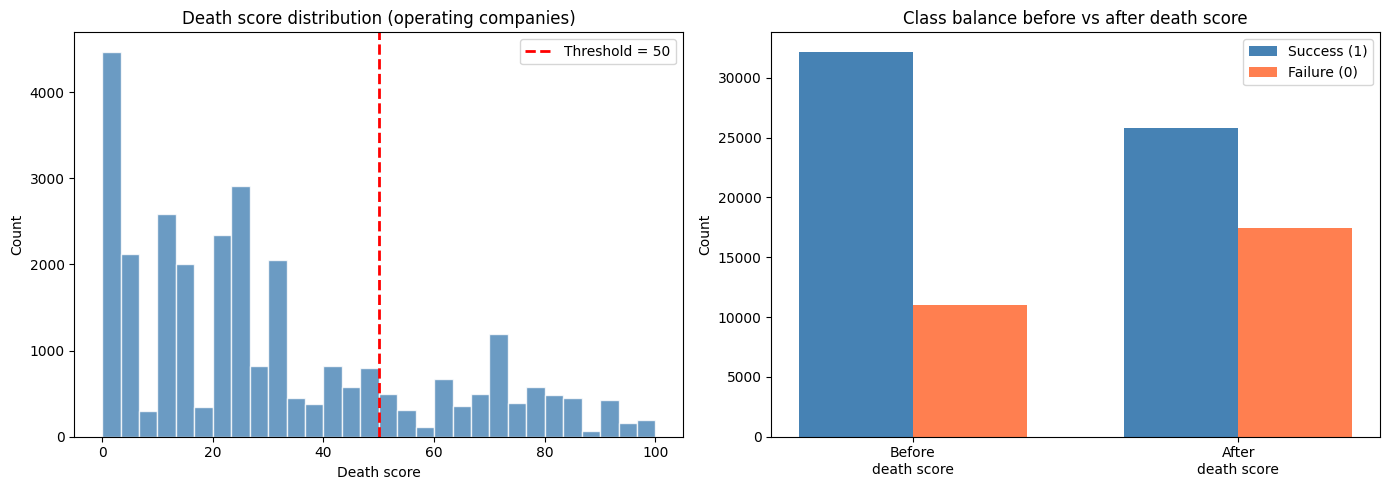

In [ ]:
# Death score distribution plot
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
scores = df.loc[op_mask, 'death_score'].dropna()
ax1.hist(scores, bins=30, edgecolor='white', alpha=0.8, color='steelblue')
ax1.axvline(DEATH_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold = {DEATH_THRESHOLD}')
ax1.set_xlabel('Death score')
ax1.set_ylabel('Count')
ax1.set_title('Death score distribution (operating companies)')
ax1.legend()

# Class balance comparison
ax2 = axes[1]
labels = ['Before\ndeath score', 'After\ndeath score']
success = [df['status_enriched'].isin(['operating', 'acquired']).sum(), df[df['target']==1].shape[0]]
failure = [(df['status_enriched']=='closed').sum(), df[df['target']==0].shape[0]]
x = np.arange(len(labels))
w = 0.35
ax2.bar(x - w/2, success, w, label='Success (1)', color='steelblue')
ax2.bar(x + w/2, failure, w, label='Failure (0)', color='coral')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel('Count')
ax2.set_title('Class balance before vs after death score')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Slim feature set + train/test split
# ============================================================

# Based on permutation importance from iteration 2:
# Top features: age_first_funding_days, industry_group, funding_span_days,
#               avg_raised_per_round, region_group, has_multiple_rounds
# Everything else had near-zero or negative importance → dropped

slim_features = [
    'age_first_funding_days',
    'funding_span_days',
    'avg_raised_per_round',
    'has_multiple_rounds',
    'industry_group',
    'region_group',
]

num_cols = ['age_first_funding_days', 'funding_span_days', 'avg_raised_per_round']
bin_cols = ['has_multiple_rounds']
cat_cols = ['industry_group', 'region_group']

X = df[slim_features].copy()
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features: {slim_features}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")

Features: ['age_first_funding_days', 'funding_span_days', 'avg_raised_per_round', 'has_multiple_rounds', 'industry_group', 'region_group']
Train: (34569, 6), Test: (8643, 6)
Train balance: {1: 0.596, 0: 0.404}


In [ ]:
# Preprocessor + all models
# ============================================================

preprocessor = ColumnTransformer([
    ('num', RobustScaler(), num_cols),
    ('bin', 'passthrough', bin_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])

models = {
    'LogReg (balanced)': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Decision Tree (balanced)': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest (balanced)': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42),
}

# Train and evaluate all models
print("=" * 75)
print("ITERATION 3: SLIM FEATURES (6) + DEATH SCORE TARGET")
print("=" * 75)
print(f"{'Model':<28} {'CV AUC':>10} {'Test AUC':>10} {'F1 closed':>10} {'Accuracy':>10}")
print("-" * 75)

results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])

    # Cross-validation
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)

    # Fit and predict
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, y_proba)
    f1_closed = f1_score(y_test, y_pred, pos_label=0)
    acc = accuracy_score(y_test, y_pred)

    results[name] = {
        'cv_auc': cv_scores.mean(), 'test_auc': test_auc,
        'f1_closed': f1_closed, 'accuracy': acc, 'pipe': pipe
    }

    print(f"{name:<28} {cv_scores.mean():>10.4f} {test_auc:>10.4f} {f1_closed:>10.4f} {acc:>10.4f}")


ITERATION 3: SLIM FEATURES (6) + DEATH SCORE TARGET
Model                            CV AUC   Test AUC  F1 closed   Accuracy
---------------------------------------------------------------------------
LogReg (balanced)                0.6704     0.6724     0.5945     0.6183
Decision Tree (balanced)         0.5649     0.5669     0.4994     0.5864
Random Forest (balanced)         0.6330     0.6377     0.5055     0.6285
KNN (k=5)                        0.6263     0.6334     0.4999     0.6215
Gradient Boosting                0.6971     0.6963     0.5344     0.6597
XGBoost                          0.6837     0.6883     0.5361     0.6586


In [9]:
# Best model
best_name = max(results, key=lambda k: results[k]['cv_auc'])
print(f"\nBest by CV AUC: {best_name}")


Best by CV AUC: Gradient Boosting


In [10]:
# CELL 8: Classification report for best model
# ============================================================

print(f"Classification report — {best_name}:")
print(classification_report(y_test, results[best_name]['pipe'].predict(X_test)))

Classification report — Gradient Boosting:
              precision    recall  f1-score   support

           0       0.60      0.48      0.53      3489
           1       0.69      0.78      0.73      5154

    accuracy                           0.66      8643
   macro avg       0.64      0.63      0.63      8643
weighted avg       0.65      0.66      0.65      8643



In [ ]:
# GridSearch on top 2 models
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# --- Gradient Boosting ---
gb_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42)),
])

gb_params = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 4, 5, 6, 7],
    'model__min_samples_leaf': [5, 10, 20, 50],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
}

gb_search = RandomizedSearchCV(
    gb_pipe, gb_params, n_iter=30, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
gb_search.fit(X_train, y_train)

y_pred = gb_search.predict(X_test)
y_proba = gb_search.predict_proba(X_test)[:, 1]

print("\n" + "=" * 60)
print("GRADIENT BOOSTING — GridSearch results")
print("=" * 60)
print(f"Best CV AUC:   {gb_search.best_score_:.4f}")
print(f"Test AUC:      {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1 closed:     {f1_score(y_test, y_pred, pos_label=0):.4f}")
print(f"Accuracy:      {accuracy_score(y_test, y_pred):.4f}")
print(f"Best params:   {gb_search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

GRADIENT BOOSTING — GridSearch results
Best CV AUC:   0.6987
Test AUC:      0.6988
F1 closed:     0.5403
Accuracy:      0.6632
Best params:   {'model__subsample': 0.9, 'model__n_estimators': 300, 'model__min_samples_leaf': 50, 'model__max_depth': 4, 'model__learning_rate': 0.05}
